# Resolution: Transfer or Correct? — Summary

1. Resolution question 

2. Response Opportunity 

3. Transfer resolution
    * RT05: Focus + Goal_Type
    * RT11: Focus * Agent + Goal_Type
    * predicted probabilities
    * what the richer model adds

4. Correct resolution
    * RC05: Focus + Goal_Type
    * RC11: Focus * Agent + Goal_Type
    * predicted probabilities
    * what the richer model adds
    
5. Transfer vs Correct synthesis
    * what is shared
    * where they diverge
    * how the RT11/RC11 structures relate
    * behavioural conclusion


Import libraries

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [92]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy.stats import chi2

1. Resolution question

**Once competing L2 responses are suppressed, how is the resulting opportunity allocated?**

2. Response opportunity

In [93]:
goal_summary_metrics = pd.read_csv("../../reports/tables/goal_summary_metrics.csv",
                                   index_col=[0, 1, 2])
goal_summary_metrics

L2_suppression  L1_shift  Correct_gain  \
Goal_Type         Agent Focus                                           
goal_frequent     0     I            0.152174  0.010870      0.141304   
                        They         0.166667  0.138889      0.027778   
                  1     I            0.375000  0.187500      0.187500   
                        They         0.500000  0.375000      0.125000   
goal_non_frequent 0     I            0.166667  0.041667      0.125000   
                        They         0.444444  0.527778     -0.083333   
                  1     I            0.437500  0.437500      0.000000   
                        They         0.500000  0.375000      0.125000   

                               Conversion_efficiency  
Goal_Type         Agent Focus                         
goal_frequent     0     I                   0.928571  
                        They                0.166667  
                  1     I                   0.500000  
                        They                0.250000  
goal_non_frequent 0     I                   0.750000  
                        They               -0.187500  
                  1     I                   0.000000  
                        They                0.250000

In [94]:
goal_summary_metrics.index.names

FrozenList(['Goal_Type', 'Agent', 'Focus'])

In [95]:
goal_summary_metrics.dtypes

L2_suppression           float64
L1_shift                 float64
Correct_gain             float64
Conversion_efficiency    float64
dtype: object

In [96]:
resolution = goal_summary_metrics[["L1_shift", "Correct_gain", "Conversion_efficiency"]]
resolution

L1_shift  Correct_gain  Conversion_efficiency
Goal_Type         Agent Focus                                               
goal_frequent     0     I      0.010870      0.141304               0.928571
                        They   0.138889      0.027778               0.166667
                  1     I      0.187500      0.187500               0.500000
                        They   0.375000      0.125000               0.250000
goal_non_frequent 0     I      0.041667      0.125000               0.750000
                        They   0.527778     -0.083333              -0.187500
                  1     I      0.437500      0.000000               0.000000
                        They   0.375000      0.125000               0.250000

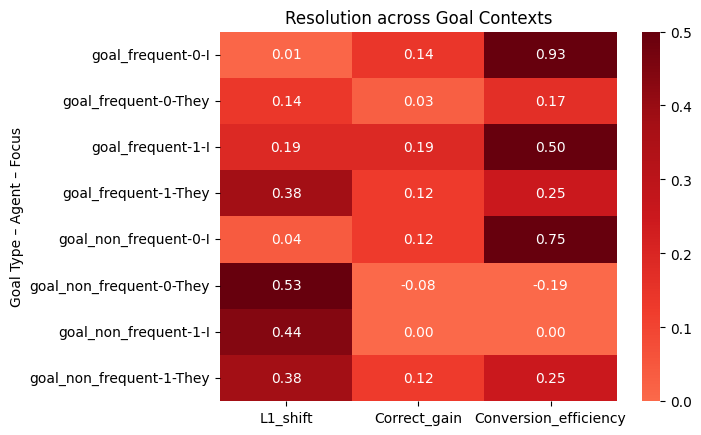

In [97]:
sns.heatmap(
    resolution,
    annot=True,
    cmap="Reds",
    center=0,
    fmt=".2f",
    vmin=0,
    vmax = 0.50
)

plt.title("Resolution across Goal Contexts")
plt.ylabel("Goal Type – Agent – Focus")
plt.xlabel("")
plt.show()

* Frequent, implicit, I: L1_shift = .01, Correct_gain = .14. Almost everything released from L2 goes correct. That’s your spectacular .93 conversion efficiency.

* Non-frequent, implicit, They: the exact opposite pathology: .53 transfer and -.08 correct gain. Suppression has occurred, but resolution has gone overwhelmingly toward transfer.

* Non-frequent, explicit, I: .44 transfer and zero correct gain. Different configuration, remarkably similar destination problem. 

* Frequent, explicit, I: .19 / .19. This is particularly interesting because here the released responses divide evenly between the two destinations.

* And the two explicit They conditions are identical in these metrics: .38 / .12 / .25, despite goal type changing.


3. Transfer resolution
    * RT05: Focus + Goal_Type
    * RT11: Focus * Agent + Goal_Type
    * predicted probabilities
    * what the richer model adds

Read data

In [98]:
subgroup_theoretical = pd.read_csv("../../data/processed/subgroup_theoretical.csv")

Create escape_L2 binary outcome

In [99]:
subgroup_theoretical["escape_L2"] = (
    subgroup_theoretical["Response_Full"] != "L2_other"
).astype(int)

Create escapees data

In [100]:
escapees = subgroup_theoretical[subgroup_theoretical["escape_L2"] == 1].copy()

Create resolved transfer binary outcome

In [101]:
escapees["resolved_transfer"] = (escapees["Response_Full"] == "L1_transfer").astype(int)

Get goal context data

In [102]:
goals_escapees = escapees[escapees["Goal_Type"] != "no_goal"].copy()

* RT05: Focus + Goal_Type

In [103]:
# Fit

RT05 = smf.logit(
    "resolved_transfer ~ Focus + Goal_Type",
    data=goals_escapees
    ).fit()

print(RT05.summary())

Optimization terminated successfully.
         Current function value: 0.649658
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:      resolved_transfer   No. Observations:                  106
Model:                          Logit   Df Residuals:                      103
Method:                           MLE   Df Model:                            2
Date:                Sat, 08 Aug 2026   Pseudo R-squ.:                 0.04273
Time:                        21:08:47   Log-Likelihood:                -68.864
converged:                       True   LL-Null:                       -71.938
Covariance Type:            nonrobust   LLR p-value:                   0.04623
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                         -0.2983      0.331     -0.901     


- reference Focus = I
- reference Goal_Type = goal_frequent
- Focus[T.they] = 0.7500
- Goal_Type[T.goal_non_frequent] = 0.6531

Moving from "I" to "They" increases the predicted probability of transfer, and moving from "frequent" to "non-frequent" goal also increases the predicted probability of transfer.

→ predicted probabilities

In [104]:
# Prediction grid

RT05_pred = pd.DataFrame({
    "Focus": ["I", "I", "They", "They"],
    "Goal_Type": ["goal_frequent", "goal_non_frequent", "goal_frequent", "goal_non_frequent"]
    })

RT05_pred

,Focus,Goal_Type
0,I,goal_frequent
1,I,goal_non_frequent
2,They,goal_frequent
3,They,goal_non_frequent


In [105]:
# Predict

RT05_pred["Predicted_probability"] = RT05.predict(RT05_pred)

RT05_pred

,Focus,Goal_Type,Predicted_probability
0,I,goal_frequent,0.425968
1,I,goal_non_frequent,0.587773
2,They,goal_frequent,0.611049
3,They,goal_non_frequent,0.751161


Focus: I to They

* frequent: .426 → .611
* non-frequent: .588 → .751

Goal: frequent to non-frequent

* I: .426 → .588
* They: .611 → .751

Conditional on having escaped L2-other responses, transfer becomes more probable under external focus and under non-frequent goals.

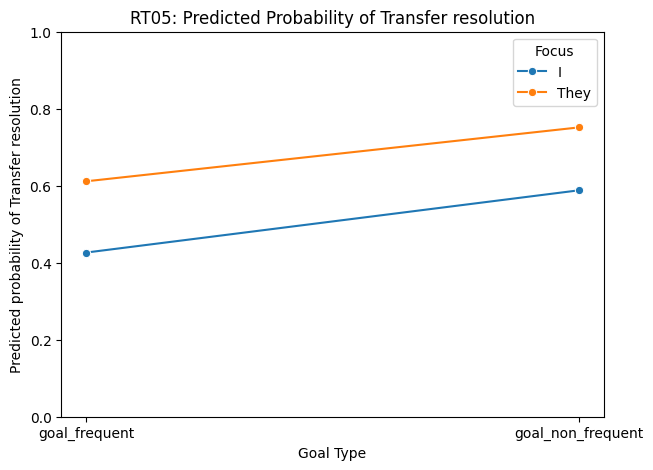

In [106]:
# RT05 predicted probabilities plot

plt.figure(figsize=(7, 5))

sns.lineplot(
    data=RT05_pred,
    x="Goal_Type",
    y="Predicted_probability",
    hue="Focus",
    marker="o"
)

plt.xticks([0, 1], ["goal_frequent", "goal_non_frequent"])
plt.ylim(0, 1)

plt.xlabel("Goal Type")
plt.ylabel("Predicted probability of Transfer resolution")
plt.title("RT05: Predicted Probability of Transfer resolution")

plt.legend(title="Focus")
plt.show()

* Goal Type: both lines rise; non-frequent goals increase predicted transfer.
* Focus: external focus increases predicted transfer.
* Roughly parallel trajectories -visually consistent with an additive model.

* RT11: Focus * Agent + Goal_Type

In [107]:
RT11 = smf.logit(
    "resolved_transfer ~ Focus * Agent + Goal_Type",
    data=goals_escapees
    ).fit()

print(RT11.summary())

Optimization terminated successfully.
         Current function value: 0.634611
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:      resolved_transfer   No. Observations:                  106
Model:                          Logit   Df Residuals:                      101
Method:                           MLE   Df Model:                            4
Date:                Sat, 08 Aug 2026   Pseudo R-squ.:                 0.06490
Time:                        21:08:47   Log-Likelihood:                -67.269
converged:                       True   LL-Null:                       -71.938
Covariance Type:            nonrobust   LLR p-value:                   0.05318
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                         -0.7155      0.425     -1.682     

- reference Focus = I
- reference Goal_Type = goal_frequent
- reference Agent = 0
- Focus[T.They] = 1.3212
- Goal_Type[T.goal_non_frequent]= 0.6518
- Agent = 0.8835
- Focus[T.They]:Agent = -1.2910

→ predicted probabilities

In [108]:
# Prediction grid

RT11_pred = pd.DataFrame({
    "Focus": [
        "I", "I", "They", "They",
        "I", "I", "They", "They"
    ],
    "Agent": [
        0, 1, 0, 1,
        0, 1, 0, 1
    ],
    "Goal_Type": [
        "goal_frequent", "goal_frequent",
        "goal_frequent", "goal_frequent",
        "goal_non_frequent", "goal_non_frequent",
        "goal_non_frequent", "goal_non_frequent"
    ]
})

In [109]:
# Predict

RT11_pred["Predicted_probability"] = RT11.predict(RT11_pred)
RT11_pred

,Focus,Agent,Goal_Type,Predicted_probability
0,I,0,goal_frequent,0.328396
1,I,1,goal_frequent,0.541914
2,They,0,goal_frequent,0.646969
3,They,1,goal_frequent,0.549407
4,I,0,goal_non_frequent,0.484104
5,I,1,goal_non_frequent,0.694214
6,They,0,goal_non_frequent,0.778610
7,They,1,goal_non_frequent,0.700593


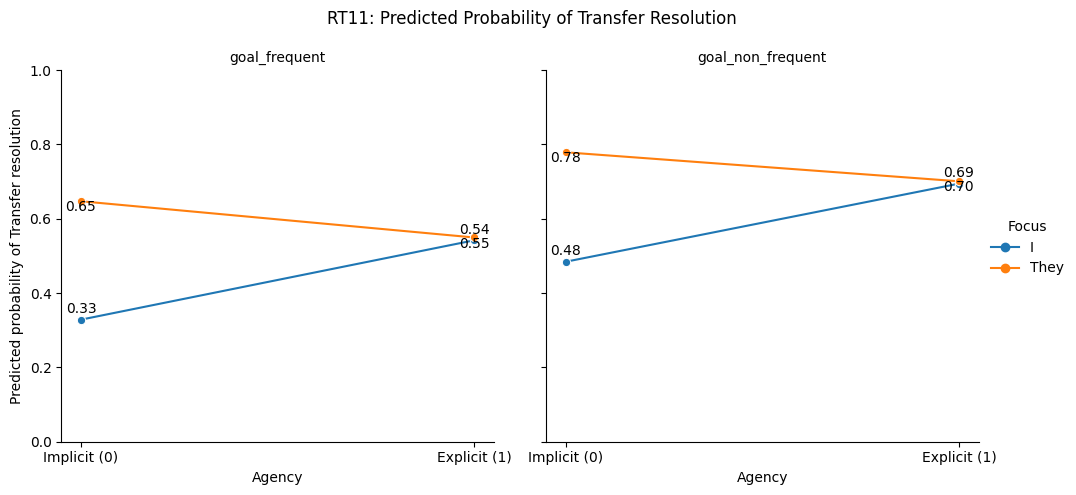

In [110]:
# RT11 predicted probabilities plot

g = sns.relplot(
    data=RT11_pred,
    x="Agent",
    y="Predicted_probability",
    hue="Focus",
    col="Goal_Type",
    kind="line",
    marker="o",
    height=5,
    aspect=1
)

g.set(
    xlim=(-0.05, 1.05),
    ylim=(0, 1),
    xticks=[0, 1]
)

g.set_xticklabels(["Implicit (0)", "Explicit (1)"])

g.set_axis_labels(
    "Agency",
    "Predicted probability of Transfer resolution"
)

g.set_titles("{col_name}")

g.figure.subplots_adjust(
    top=0.86,
    wspace=0.12
)

g.figure.suptitle(
    "RT11: Predicted Probability of Transfer Resolution"
)

# Add probability labels

for ax, goal_type in zip(g.axes.flat, RT11_pred["Goal_Type"].unique()):
    subset = RT11_pred[RT11_pred["Goal_Type"] == goal_type]
    for _, row in subset.iterrows():
        offset = -0.027 if row["Focus"] == "They" else 0.018
        ax.text(
            row["Agent"],
            row["Predicted_probability"] + offset,
            f'{row["Predicted_probability"]:.2f}',
            ha="center"
        )

plt.show()


 → what the richer model adds:

CHANGE!

4. Correct resolution
    * RC05: Focus + Goal_Type
    * RC11: Focus * Agent + Goal_Type
    * predicted probabilities
    * what the richer model adds

Create resolved correct binary outcome

In [111]:
escapees["resolved_correct"] = (escapees["Response_Full"] == "correct").astype(int)

Get goal context data

In [112]:
goals_escapees = escapees[escapees["Goal_Type"] != "no_goal"].copy()

In [113]:
# Fit

RC05 = smf.logit(
    "resolved_correct ~ Focus + Goal_Type",
    data=goals_escapees
    ).fit()

print(RC05.summary())

Optimization terminated successfully.
         Current function value: 0.651957
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:       resolved_correct   No. Observations:                  106
Model:                          Logit   Df Residuals:                      103
Method:                           MLE   Df Model:                            2
Date:                Sat, 08 Aug 2026   Pseudo R-squ.:                 0.03448
Time:                        21:08:47   Log-Likelihood:                -69.107
converged:                       True   LL-Null:                       -71.575
Covariance Type:            nonrobust   LLR p-value:                   0.08476
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                          0.1894      0.329      0.576     

- reference Focus = I
- reference Goal_Type = goal_frequent
- Focus[T.they] = - 0.6825
- Goal_Type[T.goal_non_frequent] = -0.5703

Moving from "I" to "They" decreases the predicted probability of correct responses, and moving from "frequent" to "non-frequent" goal also decreases the predicted probability of correct responses.

→ predicted probabilities

In [114]:
# Prediction grid

RC05_pred = pd.DataFrame({
    "Focus": ["I", "I", "They", "They"],
    "Goal_Type": ["goal_frequent", "goal_non_frequent", "goal_frequent", "goal_non_frequent"]
    })

RC05_pred

,Focus,Goal_Type
0,I,goal_frequent
1,I,goal_non_frequent
2,They,goal_frequent
3,They,goal_non_frequent


In [115]:
# Predict

RC05_pred["Predicted_probability"] = RC05.predict(RC05_pred)
RC05_pred

,Focus,Goal_Type,Predicted_probability
0,I,goal_frequent,0.547219
1,I,goal_non_frequent,0.405917
2,They,goal_frequent,0.379171
3,They,goal_non_frequent,0.256663


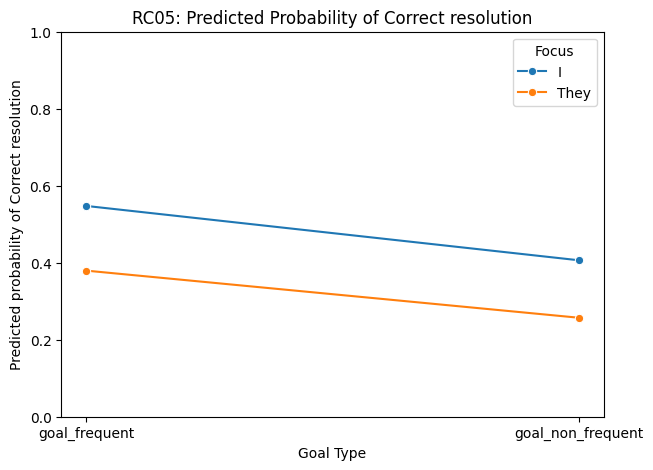

In [116]:
# RC05 predicted probabilities plot

plt.figure(figsize=(7, 5))

sns.lineplot(
    data=RC05_pred,
    x="Goal_Type",
    y="Predicted_probability",
    hue="Focus",
    marker="o"
)

plt.xticks([0, 1], ["goal_frequent", "goal_non_frequent"])
plt.ylim(0, 1)

plt.xlabel("Goal Type")
plt.ylabel("Predicted probability of Correct resolution")
plt.title("RC05: Predicted Probability of Correct resolution")

plt.legend(title="Focus")
plt.show()

The parsimonious resolution models describe complementary behavioural tendencies. Observer focus and non-frequent goals increase the probability of transfer resolution while decreasing the probability of correct resolution; self-focus and frequent goals show the reverse pattern.

* RC11: Focus * Agent + Goal_Type

In [117]:
# Fit

RC11 = smf.logit(
    "resolved_correct ~ Focus * Agent + Goal_Type",
    data=goals_escapees
    ).fit()

print(RC11.summary())

Optimization terminated successfully.
         Current function value: 0.640518
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:       resolved_correct   No. Observations:                  106
Model:                          Logit   Df Residuals:                      101
Method:                           MLE   Df Model:                            4
Date:                Sat, 08 Aug 2026   Pseudo R-squ.:                 0.05142
Time:                        21:08:47   Log-Likelihood:                -67.895
converged:                       True   LL-Null:                       -71.575
Covariance Type:            nonrobust   LLR p-value:                    0.1180
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                          0.5378      0.418      1.287     

- reference Focus = I
- reference Goal_Type = goal_frequent
- reference Agent = 0
- Focus[T.They] = -1.1899
- Goal_Type[T.goal_non_frequent]= -0.5630
- Agent = -0.7486
- Focus[T.They]:Agent = 1.1613

→ predicted probabilities

In [118]:
# Prediction grid

RC11_pred = pd.DataFrame({
    "Focus": [
        "I", "I", "They", "They",
        "I", "I", "They", "They"
    ],
    "Agent": [
        0, 1, 0, 1,
        0, 1, 0, 1
    ],
    "Goal_Type": [
        "goal_frequent", "goal_frequent",
        "goal_frequent", "goal_frequent",
        "goal_non_frequent", "goal_non_frequent",
        "goal_non_frequent", "goal_non_frequent"
    ]
})

RC11_pred

,Focus,Agent,Goal_Type
0,I,0,goal_frequent
1,I,1,goal_frequent
2,They,0,goal_frequent
3,They,1,goal_frequent
4,I,0,goal_non_frequent
5,I,1,goal_non_frequent
6,They,0,goal_non_frequent
7,They,1,goal_non_frequent


In [119]:
# Predict

RC11_pred["Predicted_probability"] = RC11.predict(RC11_pred)
RC11_pred

,Focus,Agent,Goal_Type,Predicted_probability
0,I,0,goal_frequent,0.631304
1,I,1,goal_frequent,0.447506
2,They,0,goal_frequent,0.342528
3,They,1,goal_frequent,0.440466
4,I,0,goal_non_frequent,0.493696
5,I,1,goal_non_frequent,0.315661
6,They,0,goal_non_frequent,0.228804
7,They,1,goal_non_frequent,0.309534


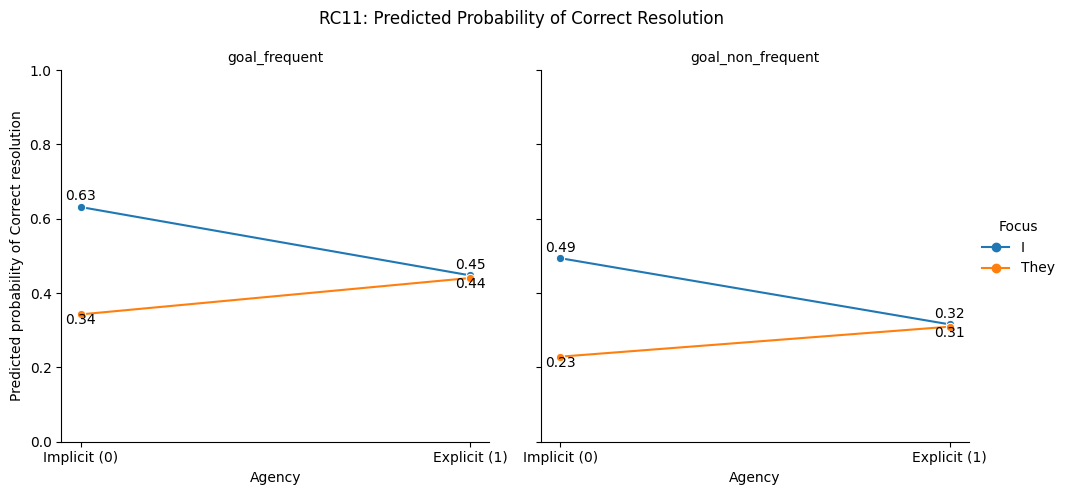

In [120]:
# RC11 predicted probabilities plot

g = sns.relplot(
    data=RC11_pred,
    x="Agent",
    y="Predicted_probability",
    hue="Focus",
    col="Goal_Type",
    kind="line",
    marker="o",
    height=5,
    aspect=1
)

g.set(
    xlim=(-0.05, 1.05),
    ylim=(0, 1),
    xticks=[0, 1]
)

g.set_xticklabels(["Implicit (0)", "Explicit (1)"])

g.set_axis_labels(
    "Agency",
    "Predicted probability of Correct resolution"
)

g.set_titles("{col_name}")

g.figure.subplots_adjust(
    top=0.86,
    wspace=0.12
)

g.figure.suptitle(
    "RC11: Predicted Probability of Correct Resolution"
)

# Add probability labels

for ax, goal_type in zip(g.axes.flat, RC11_pred["Goal_Type"].unique()):
    subset = RC11_pred[RC11_pred["Goal_Type"] == goal_type]
    for _, row in subset.iterrows():
        offset = -0.027 if row["Focus"] == "They" else 0.018
        ax.text(
            row["Agent"],
            row["Predicted_probability"] + offset,
            f'{row["Predicted_probability"]:.2f}',
            ha="center"
        )

plt.show()

→ what the richer model adds

5. Transfer vs Correct synthesis
    * what is shared
    * where they diverge
    * how the RT11/RC11 structures relate
    * behavioural conclusion